In [18]:
import numpy as np
import matplotlib.pyplot as plt

# Hand-in assignment 1

In [19]:
L = 0.75 #m 
Ls = 5 #m
d = 1/2 * 0.75 #m
m = 2 #kg
J_e = 0.1 #kgm^2
k = 5000 #N/m

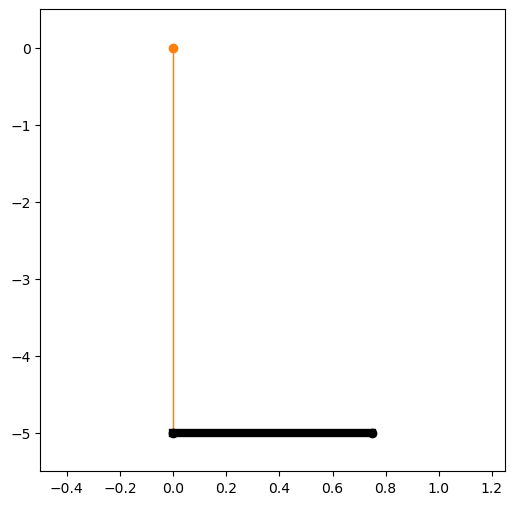

In [20]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.set_xlim(-0.5, 0.5+ L)
ax.set_ylim(-(0.5 + Ls), 0.5)
ax.plot(0, 0, 'o', color='C1');
ax.plot([0, 0], [0, -Ls], color='C1', linewidth=1);
ax.plot(0, -Ls, 'o', color='black');
ax.plot(L, -Ls, 'o', color='black');
ax.plot([0, L], [-Ls, -Ls], color='black', linewidth=6);

$$\Sigma F_x = m (\ddot{x_b} + d(-cos(\phi) \cdot \dot{\phi}^2 - sin(\phi) \ddot{\phi})) = F_{1x}$$
$$\Sigma F_y = m (\ddot{y_b} + d(-sin(\phi) \cdot \dot{\phi}^2 + cos(\phi) \ddot{\phi})) = F_{1y} - F_g$$
$$\Sigma M_{/C} = J_{/C} \ddot{\phi}$$

$$M = \vec{r} \times \vec{F} $$

$$\vec{r} = 
\begin{pmatrix}
    x_b - x_c \\
    y_b - y_c \\
\end{pmatrix}
$$

$$\vec{b} = 
\begin{pmatrix}
    x_b \\
    y_b \\
\end{pmatrix}
$$

$$\vec{F} = 
\begin{pmatrix}
    F_x \\
    F_y \\
\end{pmatrix}
= \frac{-\vec{b}}{L} \cdot  \lvert F \rvert  = -(\Delta{L}\cdot k) \frac{1}{L} \cdot \vec{b} =  -(\Delta{L}\cdot k) \frac{1}{\lvert \vec{b} \rvert} \cdot \vec{b}$$

<!-- $$1 -->

In [21]:
def ForceB(x, y, L = Ls, k = k):
    if np.sqrt(x**2 + y**2) > L:
        Fx = -k * x / np.sqrt(x**2 + y**2)
        Fy = -k * y / np.sqrt(x**2 + y**2)
        return Fx, Fy
    else:
        return 0, 0

In [22]:
print(f'Length0: {Ls}')
xs = -4.6
ys = -4.4
print(f'Length1: {np.sqrt(xs**2 + ys**2)}')
ForceB(xs, ys)
print(f'Force x: {ForceB(xs, ys)[0]:.3f}')
print(f'Force y: {ForceB(xs, ys)[1]:.3f}')

Length0: 5
Length1: 6.3655321851358195
Force x: 3613.209
Force y: 3456.113


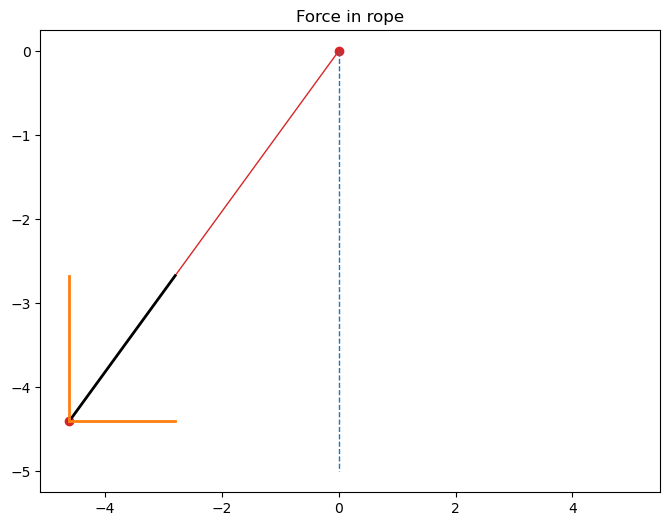

In [23]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.set_title('Force in rope')
ax.set_xlim(-0.5+xs, 0.5+ Ls)

ax.plot([0, xs], [0, ys], 'C3o-', linewidth=1);
ax.plot([0, 0], [0, -Ls], 'C0--', linewidth=1);

scale1=2000
Fx, Fy = ForceB(xs, ys)

ax.plot([xs, xs + Fx/scale1], [ys, ys + Fy/scale1], color='black', linewidth=2);
# draw force by components x and y
ax.plot([xs, xs + Fx/scale1], [ys, ys], color='C1', linewidth=2);
ax.plot([xs, xs], [ys, ys + Fy/scale1], color='C1', linewidth=2);

### 2 How many DoF
DOF:2

### 3 Equations of motions 
for $t=0$

In [24]:
phi, dphi = 0, 0
Fx = 0
J_T = J_e
g = 9.81

A = [[m, 0, -1/2 * L * m*np.sin(phi)],
    [0, m, 1/2 * L * m*np.cos(phi)],
    [0, 0, -J_T]]

b = [[1/2 * L * m*np.cos(phi) * dphi**2 + Fx],
    [1/2 * L * m*np.sin(phi) * dphi**2 - g],
    [m*g*L/4]]

x = np.linalg.solve(A, b)
print(f'ddx = {x[0][0]:.4f} m/s^2')
print(f'ddy = {x[1][0]:.4f} m/s^2')
print(f'ddphi = {x[2][0]:.4f} rad/s^2')

ddx = 0.0000 m/s^2
ddy = -8.8903 m/s^2
ddphi = 36.7875 rad/s^2


### 5 Simulation
$t: 0s \rightarrow 5 s$

In [25]:
Fx, Fy = 0, 1/2 * m * g
A = [[m, 0, -1/2 * L * m*np.sin(phi)],
    [0, m, 1/2 * L * m*np.cos(phi)],
    [0, 0, J_T]]

b = [[1/2 * L * m*np.cos(phi) * dphi**2 + Fx],
    [1/2 * L * m*np.sin(phi) * dphi**2 - m* g + Fy],
    [Fx * d * np.sin(phi) - Fy * d * np.cos(phi)]]

x = np.linalg.solve(A, b) # ddx, ddy, ddphi
x

array([[ 0.       ],
       [-8.8903125],
       [36.7875   ]])

In [26]:
x*0.02 

array([[ 0.        ],
       [-0.17780625],
       [ 0.73575   ]])

In [27]:
timestep = 0.02

t = np.arange(0, 6, timestep)
dt = t[1] - t[0]

In [28]:
Force = np.zeros((2, len(t)))
Force[0, 0] = Fx
Force[1, 0] = Fy
print(f'Force x at t=0: {Force[0, 0]:.3f}')
print(f'Force y at t=0: {Force[1, 0]:.3f}')

Force x at t=0: 0.000
Force y at t=0: -9.810


[[ 0.00000000e+00  0.00000000e+00  0.00000000e+00  8.11992094e-05]
 [ 0.00000000e+00  0.00000000e+00 -3.55612500e-03 -3.18825000e-03]
 [ 0.00000000e+00  0.00000000e+00  1.47150000e-02  2.94300000e-02]
 [ 0.00000000e+00  0.00000000e+00  4.05996047e-03  8.11948139e-03]
 [ 0.00000000e+00 -1.77806250e-01  1.83937500e-02  2.14653490e-01]
 [ 0.00000000e+00  7.35750000e-01  7.35750000e-01  7.35750000e-01]]
[[ 0.          0.          0.20299802  0.20297605]
 [ 0.         -8.8903125   9.81        9.81298701]
 [ 0.         36.7875      0.          0.        ]]


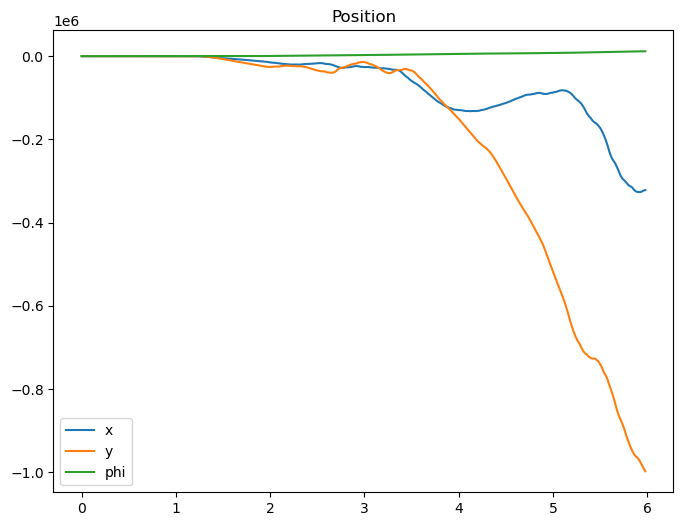

In [34]:
V = np.zeros((6, len(t)+1)) # x, y, phi, dx, dy, dphi
F = np.zeros((2, len(t)+1)) # Fx, Fy
X = np.zeros((3, len(t)+1)) # ddx, ddy, ddphi

F[:, 0] = 0, 1/2 * m * g # Fx, Fy   at t=0
V[:, 0] = 0, -5+(1/2 * m * g/k), 0, 0, 0, 0 # x, y, phi, dx, dy, dphi inital conditions

H = 5
for i in np.arange(len(t))+1:
    Fx, Fy = F[:, i-1]
    phi, dphi = V[2, i-1], V[5, i-1]

    A = [[m, 0, -1/2 * L * m*np.sin(phi)],
    [0, m, 1/2 * L * m*np.cos(phi)],
    [0, 0, J_T]]

    b = [[1/2 * L * m*np.cos(phi) * dphi**2 + Fx],
    [1/2 * L * m*np.sin(phi) * dphi**2 - m* g + Fy],
    [Fx * d * np.sin(phi) - Fy * d * np.cos(phi)]]

    x = np.linalg.solve(A, b)
    X[:, i] = x[:, 0] # ddx, ddy, ddphi

    V[-3:, i] = V[-3:, i-1] + x[:, 0]*dt # dx, dy, dphi
    V[:3, i] = V[:3, i-1] + V[-3:, i-1]*dt # x, y, phi
    F[:, i] = ForceB(V[0, i], V[1, i])


print(V[:, :4])
print(X[:, :4])

solx = V[0, :]
soly = V[1, :]
solphi = V[2, :]
soldx = V[3, :]
soldy = V[4, :]
soldphi = V[5, :]

fig, ax = plt.subplots(figsize=(8, 6))
ax.set_title('Position')
ax.plot(t, solx[:300], label='x')
ax.plot(t, soly[:300], label='y')
ax.plot(t, solphi[:300], label='phi');
ax.legend();

LAST VERSION BELOW

In [30]:
# sol = np.zeros((3, len(t))) #vector for ddx, ddy, ddphi
# V = np.zeros((6, len(t))) #xb, dxb, yb, dyb, phi, dphi
# initial_conditions = [0, 0, 0, 0, 0, 0] #xb, dxb, yb, dyb, phi, dphi
# V[:, 0] = initial_conditions


# for i in range(5):
#     phi, dphi, xb, dxb, yb, dyb = V[:, i]
#     Fx, Fy = Force[:, i]
#     # Force[:, i+1] = Fx, Fy
#     A = [[m, 0, -1/2 * L * m*np.sin(phi)],
#     [0, m, 1/2 * L * m*np.cos(phi)],
#     [0, 0, J_T]]

#     b = [[1/2 * L * m*np.cos(phi) * dphi**2 + Fx],
#     [1/2 * L * m*np.sin(phi) * dphi**2 - m* g + Fy],
#     [Fx * d * np.sin(phi) - Fy * d * np.cos(phi)]]

#     x = np.linalg.solve(A, b)
#     sol[:, i+1] = x[:, 0]
#     #multipy all element in x by timestep
#     V[1::2, i+1] = V[1::2, i] + x[:, 0] * timestep
#     V[::2, i+1] = V[1:2, i] + V[1::2, i] * timestep
#     # V[::2, i+1] = V[::2, i] + x[:, 0] * 1/2 * timestep**2 + V[1::2, i+1] * timestep
#     # print(V[:, i], x[:, 0])
#     Force[:, i+1] = ForceB(V[0, i+1], V[2, i+1])
#     print(f'Force x at t={t[i]:.2f}: {Force[0, i]:.3f}')
#     print(f'Force y at t={t[i]:.2f}: {Force[1, i]:.3f}, y = {V[2, i]:.3f}')
#     print("---")
#     # print("Force")
#     # print(Force[:, i])
# # print(V[:, :2])
# # fig, ax = plt.subplots(figsize=(8, 6))
# # ax.set_title('x(t)')
# # ax.plot(t, V[0, :], label='x')
# # ax.plot(t, V[2, :], label='y')
# # ax.legend();
# fig, ax = plt.subplots(figsize=(6, 3))
# ax.set_title('ddxb(t)')
# ax.plot(t, sol[2, :]);

In [31]:
# from scipy.integrate import solve_ivp
# import numpy as np

# # Define a function representing the system of differential equations
# def my_system(t, y):
#     # Unpack the variables (second derivatives)
#     ddot_xb, ddot_yb, ddot_phi = y
    
#     # Known constants
# #    m =  # known mass
# #    L =  # known length
#     J_T =  J_e# known moment of inertia
# #    d =  # known distance to the center of mass
# #    g =  # known gravitational acceleration
    
#     # Define the equations for the second derivatives
#     ddot_xb_dt =  # Define the equation for the second derivative ddot_xb/dt based on the system's equations
#     ddot_yb_dt =  # Define the equation for the second derivative ddot_yb/dt
#     ddot_phi_dt =  # Define the equation for the second derivative ddot_phi/dt
    
#     return [ddot_xb_dt, ddot_yb_dt, ddot_phi_dt]

# # Initial conditions for ddot_xb, ddot_yb, and ddot_phi
# initial_ddot_xb =  # Initial second derivative of x_b function of time t
# initial_ddot_yb =  # Initial second derivative of y_b function of time t
# initial_ddot_phi =  # Initial second derivative of phi function of time t

# initial_conditions = [initial_ddot_xb, initial_ddot_yb, initial_ddot_phi]

# # Time span
# t_span = (0, 5)  # Time range from 0 to 5 seconds

# # Solve the system using solve_ivp
# solution = solve_ivp(my_system, t_span, initial_conditions, t_eval=timesteps)

# # Access the solution
# time = solution.t
# ddot_xb_values = solution.y[0]  # ddot_xb values at each time step
# ddot_yb_values = solution.y[1]  # ddot_yb values at each time step
# ddot_phi_values = solution.y[2]  # ddot_phi values at each time step

# # Print or use the solution as needed
# print("Time:", time)
# print("ddot_xb values at each time step:", ddot_xb_values)
# print("ddot_yb values at each time step:", ddot_yb_values)
# print("ddot_phi values at each time step:", ddot_phi_values)


In [32]:
# def func(t, state, sigma, beta, rho):
#     ddx, ddy, ddphi = state
     
#     dx = sigma * (y - x)
#     dy = x * (rho - z) - y
#     dz = x * y - beta * z
     
#     return [dx, dy, dz]
 
# sigma = 10.0
# beta = 8.0 / 3.0
# rho = 28.0
 
# p = (sigma, beta, rho)  # Parameters of the system
 
# y0 = [-1.0, 1.0, 1.0]  # Initial state of the system

In [33]:
# import numpy as np
# from scipy.integrate import solve_ivp

# # Define your functions f1, f2, f3 that represent your second derivative equations

# def equations(t, state):
#     x, y, phi, vx, vy, omega = state
    
#     Fx, Fy = ForceB(x, y)
#     # Define your equations here
#     dx_dt = vx
#     dy_dt = vy
#     dphi_dt = omega
#     domega_dt = 1/J_e * (Fx * d * np.sin(phi) - Fy * d * np.cos(phi))
#     dvx_dt = Fx / m + d *(np.sin(phi) * domega_dt + np.cos(phi) * omega**2)
#     dvy_dt = Fy / m - g + d(-np.cos(phi) * domega_dt + d * np.sin(phi) * omega**2)
#     A = [[m, 0, -1/2 * L * m*np.sin(phi)],
#     [0, m, 1/2 * L * m*np.cos(phi)],
#     [0, 0, J_T]]

#     b = [[1/2 * L * m*np.cos(phi) * dphi**2 + Fx],
#     [1/2 * L * m*np.sin(phi) * dphi**2 - m* g + Fy],
#     [Fx * d * np.sin(phi) - Fy * d * np.cos(phi)]]

#     x = np.linalg.solve(A, b)
#     # sol[:, i+1] = x[:, 0]
#     ddx_dt, ddy_dt, domega_dt = x[:, 0]
#     return [dx_dt, dy_dt, dphi_dt, ddx_dt, ddy_dt, domega_dt]

# # Initial conditions
# initial_state = [0,0,0,0,0,0] #[x0, y0, phi0, vx0, vy0, omega0]  # Replace x0, y0, phi0, etc., with your initial values

# # Time span
# t_span = (0, 5)  # Replace with your desired time range

# # Solve the system using solve_ivp
# # Fx, Fy = 0, 0
# solution = solve_ivp(equations, t_span, initial_state, t_eval=np.linspace(0, 5, 25))

# # Access the solution
# time = solution.t
# x_values = solution.y[0]  # x values at each time step
# y_values = solution.y[1]  # y values at each time step
# phi_values = solution.y[2]  # phi values at each time step
# vx_values = solution.y[3]  # vx values at each time step
# vy_values = solution.y[4]  # vy values at each time step
# omega_values = solution.y[5]  # omega values at each time step

# fig, ax = plt.subplots(figsize=(8, 6))
# ax.set_title('y(t)')
# ax.plot(time, y_values, label='x')
